In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv("/content/upi_fraud_dataset.csv")

data.head()

,transaction_id,timestamp,amount,sender_id,receiver_id,sender_account_age_days,receiver_is_new,no_of_transactions_last_24hrs,avg_transaction_amount_user,transaction_type,device_changed,ip_changed,failed_attempts_before_txn,suspicious_keywords_flag,is_contact_saved,is_fraud
0,1,2024-07-04 21:47:02,18727.63,U620,U450,599,0,12,1862.75,merchant_payment,0,0,3,0,0,0
1,2,2023-01-01 02:08:53,47535.76,U435,U393,1108,0,26,2959.15,transfer,0,0,1,0,1,0
2,3,2024-05-04 15:02:21,36599.97,U691,U498,1632,0,5,1127.79,merchant_payment,0,0,1,0,1,0
3,4,2024-05-19 10:09:04,29933.33,U992,U789,302,0,0,261.41,request_money,0,0,2,1,1,0
4,5,2023-11-25 12:27:33,7801.78,U373,U708,1264,0,5,665.21,transfer,0,0,1,0,1,0


Data Preprocessing

In [3]:
data = data.drop(["transaction_id", "timestamp", "sender_id", "receiver_id"], axis=1)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["transaction_type"] = le.fit_transform(data["transaction_type"])

In [6]:
X = data.drop("is_fraud", axis=1)
y = data["is_fraud"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Models


🔹 Logistic Regression

In [9]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

🔹 Random Forest

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Evaluation

In [11]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.917
Random Forest Accuracy: 0.939


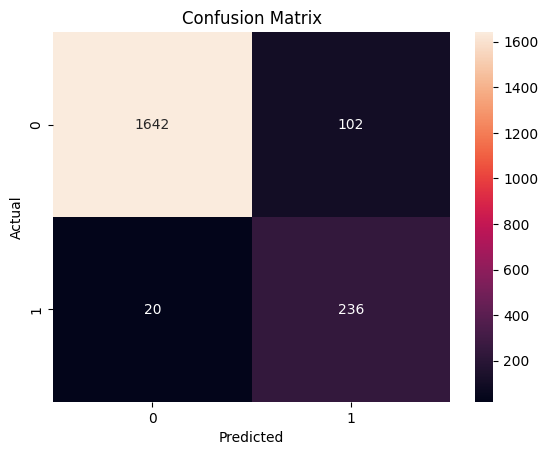

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1744
           1       0.70      0.92      0.79       256

    accuracy                           0.94      2000
   macro avg       0.84      0.93      0.88      2000
weighted avg       0.95      0.94      0.94      2000



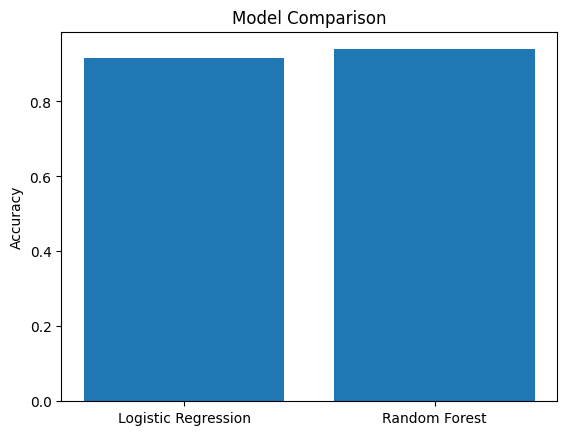

In [14]:
models = ["Logistic Regression", "Random Forest"]
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

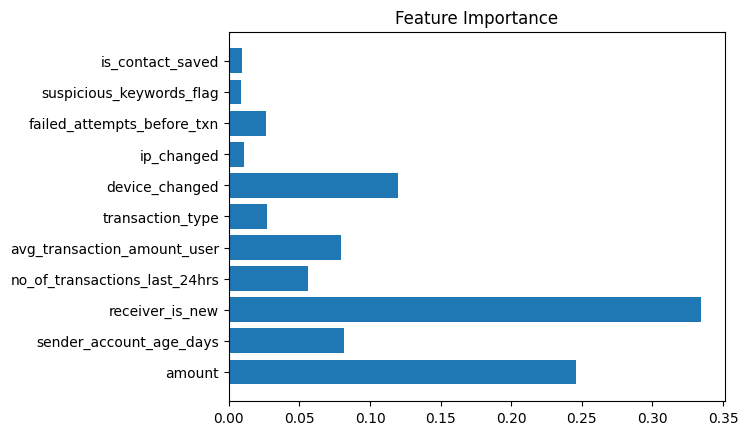

In [15]:
importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [16]:
import joblib
joblib.dump(rf, "fraud_model.pkl")

['fraud_model.pkl']